In [1]:
import pandas as pd 
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.ensemble import IsolationForest
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
import scipy.stats as stats
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.decomposition import PCA

In [2]:
df_clean = pd.read_csv('../data/data_clean.csv')
print(df_clean.columns)
df_labels = df_clean.copy()[['class_primary','class_secondary','attack']]
df_names = df_clean['english_name']
df_data = df_clean.drop(columns=['english_name','class_primary','class_secondary','attack'])

Index(['gen', 'english_name', 'percent_male', 'percent_female', 'height_m',
       'weight_kg', 'capture_rate', 'base_egg_steps', 'hp', 'attack',
       'defense', 'sp_attack', 'sp_defense', 'speed', 'against_normal',
       'against_fire', 'against_water', 'against_electric', 'against_grass',
       'against_ice', 'against_fighting', 'against_poison', 'against_ground',
       'against_flying', 'against_psychict', 'against_bug', 'against_rock',
       'against_ghost', 'against_dragon', 'against_dark', 'against_steel',
       'against_fairy', 'votes_first', 'votes_top_6', 'num_abilities',
       'evo_length', 'has_mega_evolution', 'has_gigantamax', 'rarity',
       'class_primary', 'class_secondary'],
      dtype='object')


### Linear regression model with hand picking features

In [3]:

# Prepare features and target
X = df_data
y = df_labels['attack']

# Add constant for intercept
X_const = sm.add_constant(X.select_dtypes(include=[np.number]))

# Fit OLS linear regression
model = sm.OLS(y, X_const).fit()

# Show model summary
print(model.summary())
vif_data = pd.DataFrame()
vif_data["feature"] = X_const.columns
vif_data["VIF"] = [variance_inflation_factor(X_const.values, i) for i in range(X_const.shape[1])]

print("Variance Inflation Factor (VIF) for each variable:")
print(vif_data.sort_values('VIF', ascending=False))

                            OLS Regression Results                            
Dep. Variable:                 attack   R-squared:                       0.570
Model:                            OLS   Adj. R-squared:                  0.554
Method:                 Least Squares   F-statistic:                     35.35
Date:                Sun, 09 Nov 2025   Prob (F-statistic):          1.08e-153
Time:                        22:47:58   Log-Likelihood:                -4496.7
No. Observations:                1024   AIC:                             9069.
Df Residuals:                     986   BIC:                             9257.
Df Model:                          37                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                 53.3344     12

In [4]:
# Drop 'against_dragon' from X_const and recalculate VIF
X_const_vif = X_const.drop(columns=['votes_top_6','against_dragon','against_flying','against_ground','base_egg_steps','against_dark','against_fighting'])

vif_data_new = pd.DataFrame()
vif_data_new["feature"] = X_const_vif.columns
vif_data_new["VIF"] = [variance_inflation_factor(X_const_vif.values, i) for i in range(X_const_vif.shape[1])]

print("Variance Inflation Factor (VIF) after dropping 'against_dragon':")
print(vif_data_new.sort_values('VIF', ascending=False))

Variance Inflation Factor (VIF) after dropping 'against_dragon':
               feature         VIF
0                const  201.687331
15    against_electric    2.504447
14       against_water    2.476942
6         capture_rate    2.373056
20         against_bug    2.362464
5            weight_kg    2.255531
12      against_normal    2.229696
18      against_poison    2.147977
21        against_rock    2.115602
13        against_fire    2.065466
8              defense    2.061142
9            sp_attack    2.045707
4             height_m    2.008260
10          sp_defense    1.954001
16       against_grass    1.890936
7                   hp    1.877060
30              rarity    1.740652
2         percent_male    1.737665
3       percent_female    1.707691
19    against_psychict    1.700835
11               speed    1.619598
24       against_fairy    1.613637
22       against_ghost    1.535468
23       against_steel    1.525332
17         against_ice    1.496350
26       num_abilities   

In [5]:
# Refit OLS linear regression using X_const_vif and attack as target
# Calculate new alpha for multiple comparisons (Bonferroni correction)
n_predictors = X_const_vif.shape[1] - 1  # exclude intercept
alpha = 1 - 0.95**(1 / n_predictors)
print(f"Adjusted alpha for multiple comparisons (Bonferroni-like): {alpha:.6f}")

model_vif = sm.OLS(y, X_const_vif).fit()
print(model_vif.summary())

# Print all predictors with p-value less than adjusted alpha (statistically significant)
significant_predictors = model_vif.pvalues[model_vif.pvalues < alpha]
print("Statistically significant predictors (p < adjusted alpha):")
print(significant_predictors)

Adjusted alpha for multiple comparisons (Bonferroni-like): 0.001708
                            OLS Regression Results                            
Dep. Variable:                 attack   R-squared:                       0.557
Model:                            OLS   Adj. R-squared:                  0.544
Method:                 Least Squares   F-statistic:                     41.68
Date:                Sun, 09 Nov 2025   Prob (F-statistic):          3.97e-153
Time:                        22:47:58   Log-Likelihood:                -4511.7
No. Observations:                1024   AIC:                             9085.
Df Residuals:                     993   BIC:                             9238.
Df Model:                          30                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------

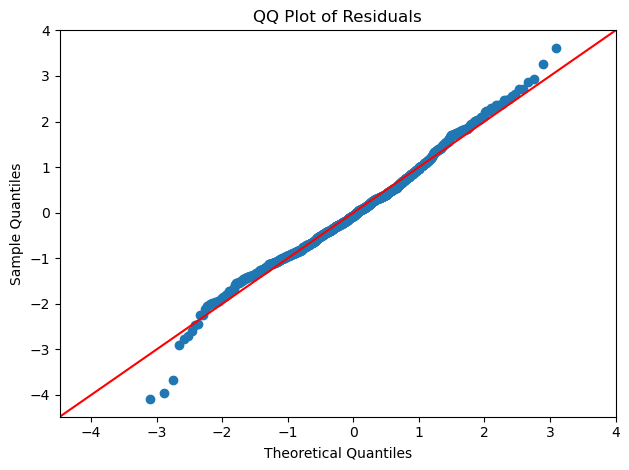

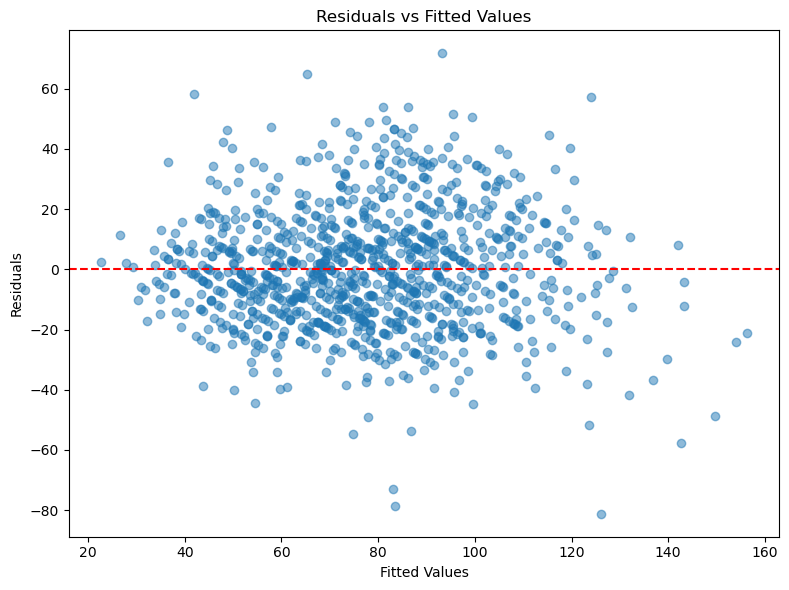

In [6]:
# QQ plot of residuals
residuals = model_vif.resid
sm.qqplot(residuals, line='45', fit=True)
plt.title("QQ Plot of Residuals")
plt.tight_layout()
plt.show()

# Residual plot (fitted values vs residuals)
fitted = model_vif.fittedvalues
plt.figure(figsize=(8, 6))
plt.scatter(fitted, residuals, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values")
plt.tight_layout()
plt.show()

                            OLS Regression Results                            
Dep. Variable:                 attack   R-squared:                       0.515
Model:                            OLS   Adj. R-squared:                  0.510
Method:                 Least Squares   F-statistic:                     107.7
Date:                Sun, 09 Nov 2025   Prob (F-statistic):          1.03e-151
Time:                        22:47:59   Log-Likelihood:                -4558.3
No. Observations:                1024   AIC:                             9139.
Df Residuals:                    1013   BIC:                             9193.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const             5.7833      6.162      0.938

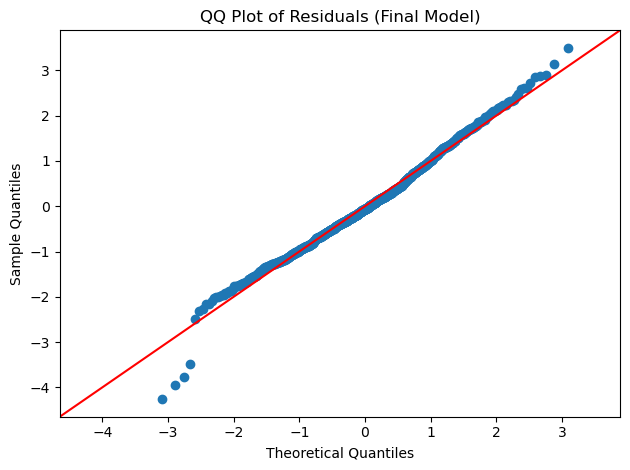

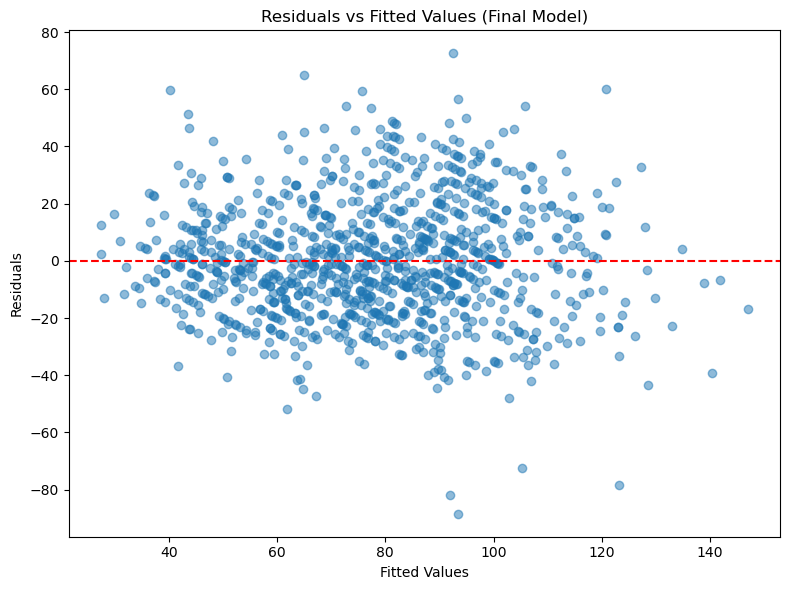

Variance Inflation Factor (VIF) for final model variables:
          feature        VIF
1    percent_male   1.160651
8    against_fire   1.178407
10  against_fairy   1.191384
9   against_water   1.251310
7           speed   1.407573
3              hp   1.422528
4         defense   1.643729
5       sp_attack   1.754701
6      sp_defense   1.815390
2    capture_rate   2.161607
0           const  89.357189


In [7]:
# Drop specified columns from X_const_vif
cols_to_keep = [
    'const', 'percent_male', 'capture_rate', 'hp', 'defense', 'sp_attack',
    'sp_defense', 'speed', 'against_fire', 'against_water', 'against_fairy'
]
X_const_final = X_const_vif[cols_to_keep]

# Fit OLS linear regression
model_final = sm.OLS(y, X_const_final).fit()
print(model_final.summary())

# QQ plot of residuals
residuals_final = model_final.resid
sm.qqplot(residuals_final, line='45', fit=True)
plt.title("QQ Plot of Residuals (Final Model)")
plt.tight_layout()
plt.show()

# Residual plot (fitted values vs residuals)
fitted_final = model_final.fittedvalues
plt.figure(figsize=(8, 6))
plt.scatter(fitted_final, residuals_final, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values (Final Model)")
plt.tight_layout()
plt.show()

# VIF calculation
vif_final = pd.DataFrame()
vif_final["feature"] = X_const_final.columns
vif_final["VIF"] = [variance_inflation_factor(X_const_final.values, i) for i in range(X_const_final.shape[1])]
print("Variance Inflation Factor (VIF) for final model variables:")
print(vif_final.sort_values('VIF', ascending=True))

### Generalised Regression (poisson, gamma)

Poisson Regression Summary:
                 Generalized Linear Model Regression Results                  
Dep. Variable:                 attack   No. Observations:                 1024
Model:                            GLM   Df Residuals:                     1013
Model Family:                 Poisson   Df Model:                           10
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -6152.0
Date:                Sun, 09 Nov 2025   Deviance:                       6053.1
Time:                        22:47:59   Pearson chi2:                 5.88e+03
No. Iterations:                     4   Pseudo R-squ. (CS):             0.9973
Covariance Type:            nonrobust                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const             

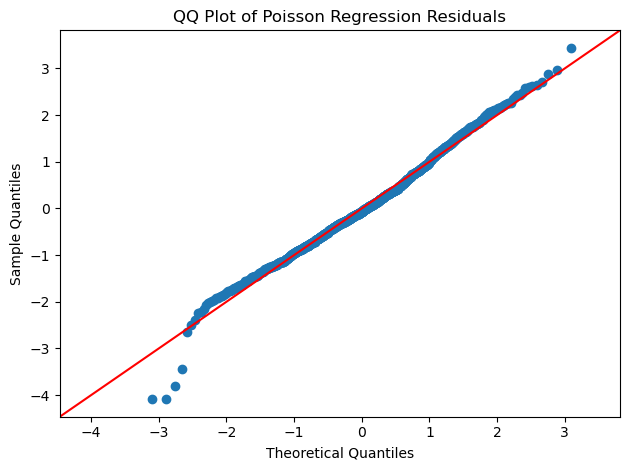

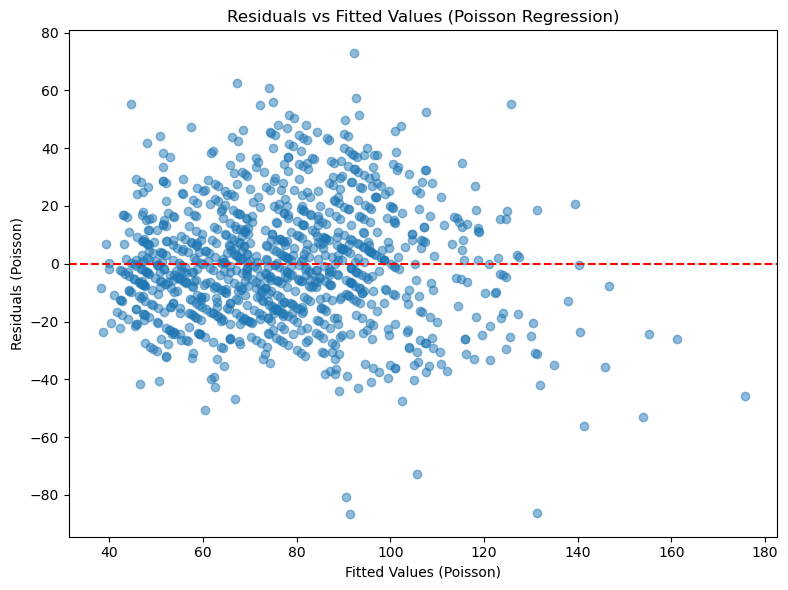

In [8]:
from statsmodels.genmod.generalized_linear_model import GLM
from statsmodels.genmod import families

# Poisson regression (log link)
poisson_model = GLM(y, X_const_final, family=families.Poisson()).fit()
print("Poisson Regression Summary:")
print(poisson_model.summary())

# Residuals
poisson_residuals = poisson_model.resid_response

# QQ plot of residuals
sm.qqplot(poisson_residuals, line='45', fit=True)
plt.title("QQ Plot of Poisson Regression Residuals")
plt.tight_layout()
plt.show()

# Residual plot (fitted values vs residuals)
poisson_fitted = poisson_model.fittedvalues
plt.figure(figsize=(8, 6))
plt.scatter(poisson_fitted, poisson_residuals, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Fitted Values (Poisson)")
plt.ylabel("Residuals (Poisson)")
plt.title("Residuals vs Fitted Values (Poisson Regression)")
plt.tight_layout()
plt.show()


c:\Users\jenda\miniconda3\Lib\site-packages\statsmodels\genmod\families\links.py:13: FutureWarning: The log link alias is deprecated. Use Log instead. The log link alias will be removed after the 0.15.0 release.
  warnings.warn(


Gamma Regression Summary:
                 Generalized Linear Model Regression Results                  
Dep. Variable:                 attack   No. Observations:                 1024
Model:                            GLM   Df Residuals:                     1013
Model Family:                   Gamma   Df Model:                           10
Link Function:                    log   Scale:                        0.081263
Method:                          IRLS   Log-Likelihood:                -4604.2
Date:                Sun, 09 Nov 2025   Deviance:                       93.481
Time:                        22:48:00   Pearson chi2:                     82.3
No. Iterations:                    18   Pseudo R-squ. (CS):             0.6347
Covariance Type:            nonrobust                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const             3.

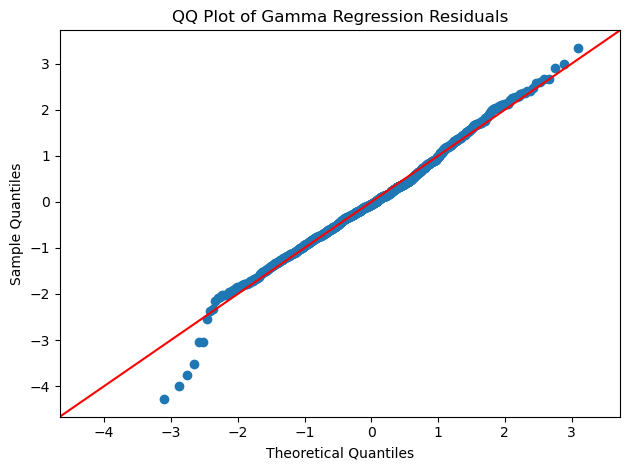

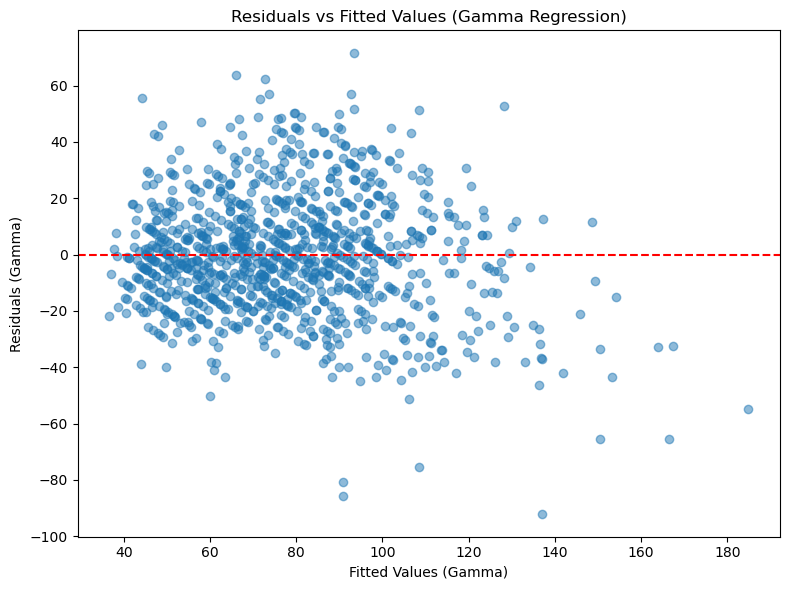

In [9]:
# Gamma regression (log link) using X_const_final
gamma_model = GLM(y, X_const_final, family=families.Gamma(link=families.links.log())).fit()
print("Gamma Regression Summary:")
print(gamma_model.summary())

# Residuals
gamma_residuals = gamma_model.resid_response

# QQ plot of residuals
sm.qqplot(gamma_residuals, line='45', fit=True)
plt.title("QQ Plot of Gamma Regression Residuals")
plt.tight_layout()
plt.show()

# Residual plot (fitted values vs residuals)
gamma_fitted = gamma_model.fittedvalues
plt.figure(figsize=(8, 6))
plt.scatter(gamma_fitted, gamma_residuals, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Fitted Values (Gamma)")
plt.ylabel("Residuals (Gamma)")
plt.title("Residuals vs Fitted Values (Gamma Regression)")
plt.tight_layout()
plt.show()

### Comparison, summary

In [10]:
# Compare models by AIC
print("AIC Comparison:")
print(f"Linear Regression (Final): {model_final.aic:.2f}")
print(f"Poisson Regression: {poisson_model.aic:.2f}")
print(f"Gamma Regression: {gamma_model.aic:.2f}")

AIC Comparison:
Linear Regression (Final): 9138.53
Poisson Regression: 12326.06
Gamma Regression: 9230.38
